In [1]:
import pandas as pd

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
import seaborn as sns
%matplotlib inline

In [5]:
df =  pd.read_csv('Algerian_forest_fires_dataset_UPDATE.csv' , header=1)

In [6]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire


In [7]:
df[df.isnull().any(axis=1)]

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes
122,Sidi-Bel Abbes Region Dataset,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
167,14,07,2012,37,37,18,0.2,88.9,12.9,14.6 9,12.5,10.4,fire,NaN


In [12]:
df.loc[:122,"Region"]=0
df.loc[122:,"Region"]=1

In [13]:
df.head()

,day,month,year,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,01,06,2012,29,57,18,0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0.0
1,02,06,2012,29,61,13,1.3,64.4,4.1,7.6,1,3.9,0.4,not fire,0.0
2,03,06,2012,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0.0
3,04,06,2012,25,89,13,2.5,28.6,1.3,6.9,0,1.7,0,not fire,0.0
4,05,06,2012,27,77,16,0,64.8,3,14.2,1.2,3.9,0.5,not fire,0.0


In [15]:
df[["Region"]]= df[["Region"]].astype(int)

In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 246 entries, 0 to 245
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   day          246 non-null    object
 1   month        245 non-null    object
 2   year         245 non-null    object
 3   Temperature  245 non-null    object
 4    RH          245 non-null    object
 5    Ws          245 non-null    object
 6   Rain         245 non-null    object
 7   FFMC         245 non-null    object
 8   DMC          245 non-null    object
 9   DC           245 non-null    object
 10  ISI          245 non-null    object
 11  BUI          245 non-null    object
 12  FWI          245 non-null    object
 13  Classes      244 non-null    object
 14  Region       246 non-null    int64 
dtypes: int64(1), object(14)
memory usage: 29.0+ KB


In [19]:
df=df.dropna().reset_index(drop=True)

In [20]:
df=df.drop(122)

In [22]:
df.columns = df.columns.str.strip()

In [25]:
df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']] = df[['day', 'month', 'year', 'Temperature', 'RH', 'Ws']].astype(int)

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   day          243 non-null    int64  
 1   month        243 non-null    int64  
 2   year         243 non-null    int64  
 3   Temperature  243 non-null    int64  
 4   RH           243 non-null    int64  
 5   Ws           243 non-null    int64  
 6   Rain         243 non-null    float64
 7   FFMC         243 non-null    float64
 8   DMC          243 non-null    float64
 9   DC           243 non-null    float64
 10  ISI          243 non-null    float64
 11  BUI          243 non-null    float64
 12  FWI          243 non-null    float64
 13  Classes      243 non-null    object 
 14  Region       243 non-null    int64  
dtypes: float64(7), int64(7), object(1)
memory usage: 30.4+ KB


In [33]:
objects = [features for features in df.columns if df[features].dtype=='O']

In [34]:
for i in objects:
    if i!= 'Classes':
        df[i] = df[i].astype(int)

In [38]:
df['Classes'] = df['Classes'].str.strip().str.lower()

In [39]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

In [40]:
df.to_csv('Algerian_cleaned.csv',index=False)

EDA

In [41]:
df_copy = df.drop(['day','month','year'],axis=1)

In [42]:
df_copy.head()

,Temperature,RH,Ws,Rain,FFMC,DMC,DC,ISI,BUI,FWI,Classes,Region
0,29,57,18,0.0,65.7,3.4,7.6,1.3,3.4,0.5,not fire,0
1,29,61,13,1.3,64.4,4.1,7.6,1.0,3.9,0.4,not fire,0
2,26,82,22,13.1,47.1,2.5,7.1,0.3,2.7,0.1,not fire,0
3,25,89,13,2.5,28.6,1.3,6.9,0.0,1.7,0.0,not fire,0
4,27,77,16,0.0,64.8,3.0,14.2,1.2,3.9,0.5,not fire,0


In [43]:
df_copy['Classes'] = np.where(df_copy['Classes'].str.contains('not fire'),0,1)

In [46]:
df['Classes'].value_counts()

Classes
fire        137
not fire    106
Name: count, dtype: int64

In [50]:
corr = df_copy.corr(numeric_only=True)

<Axes: >

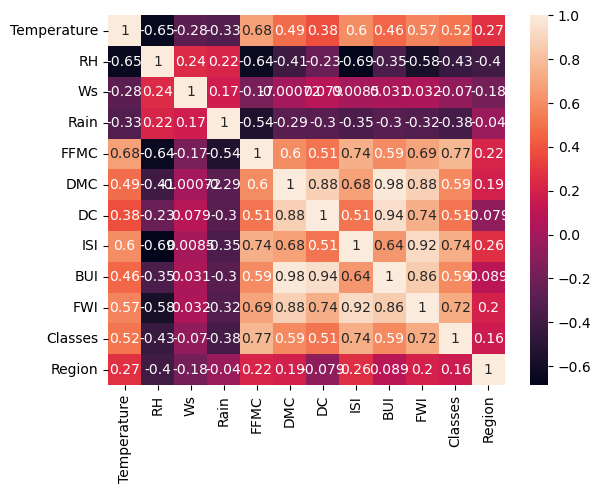

In [52]:
sns.heatmap(corr,annot=True)

In [60]:
cols = ['Temperature', 'RH', 'Ws', 'Rain', 'FFMC', 'DMC', 'DC', 'ISI', 'BUI',
       'FWI', 'Region']

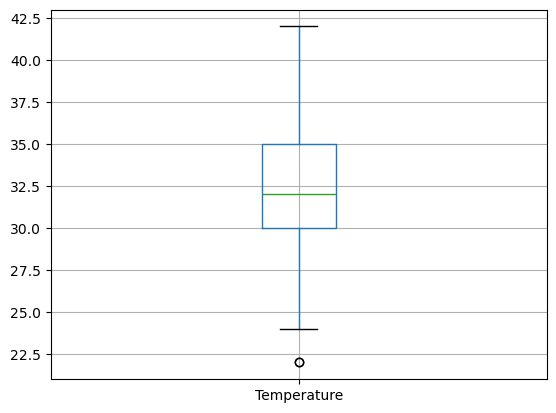

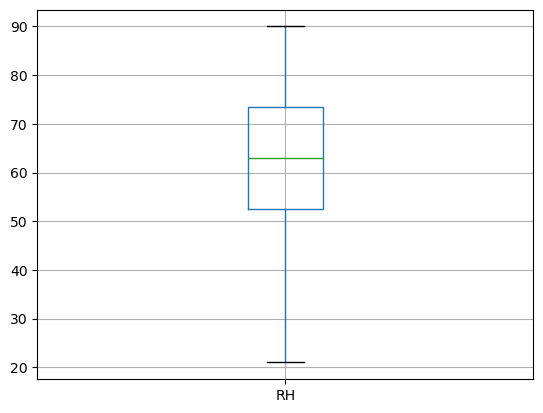

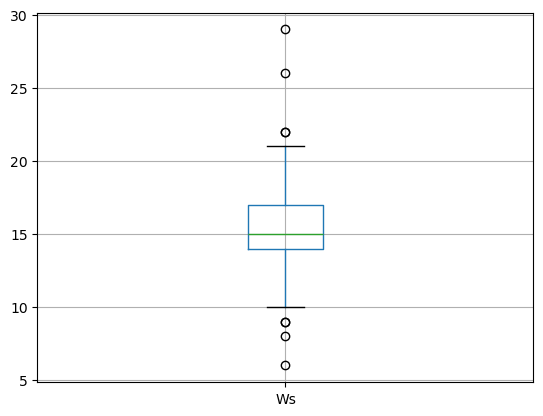

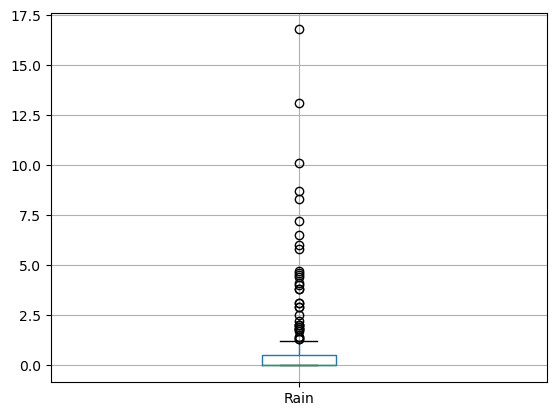

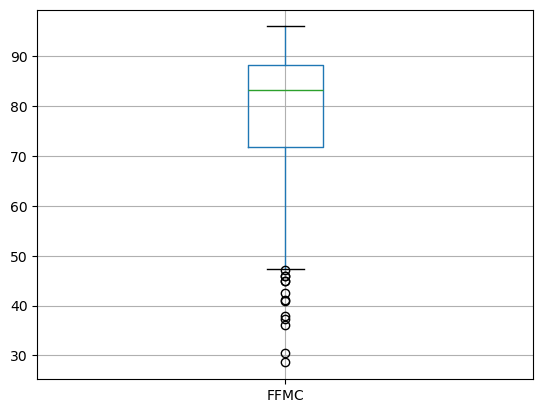

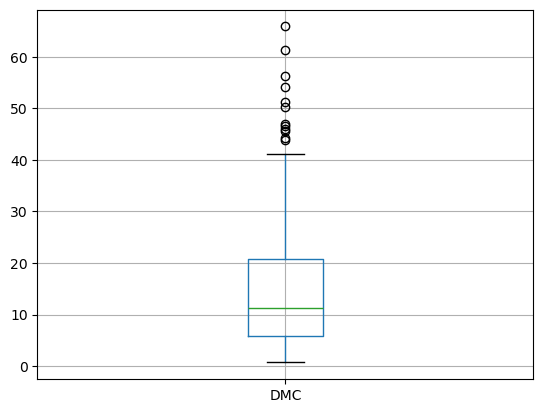

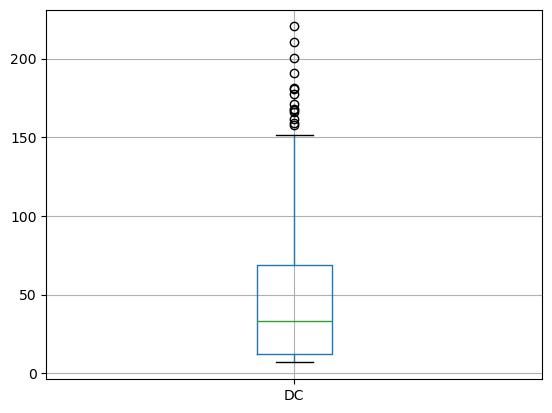

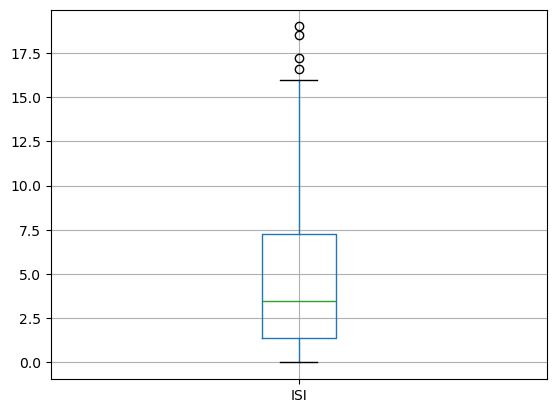

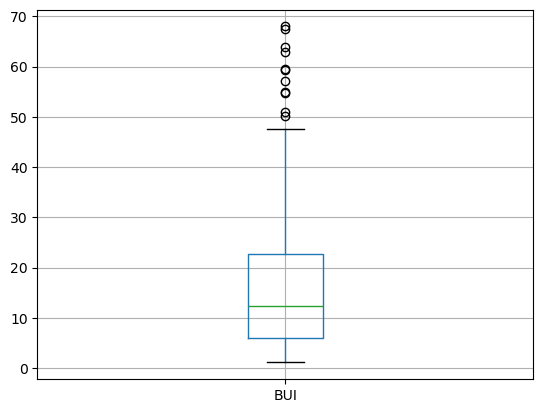

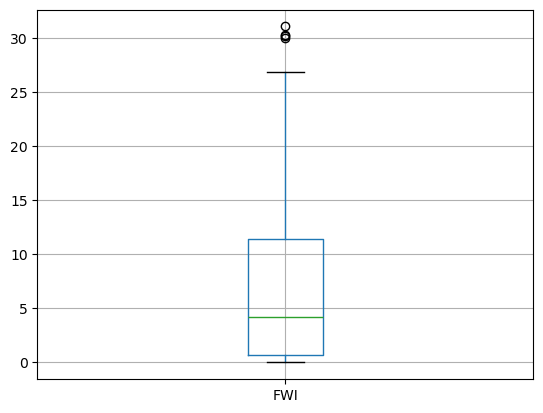

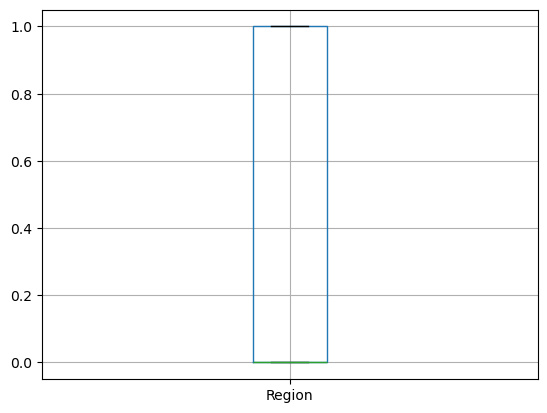

In [63]:
for col in cols:
    df_copy.boxplot(column = col)
    plt.show()

<Axes: xlabel='month', ylabel='count'>

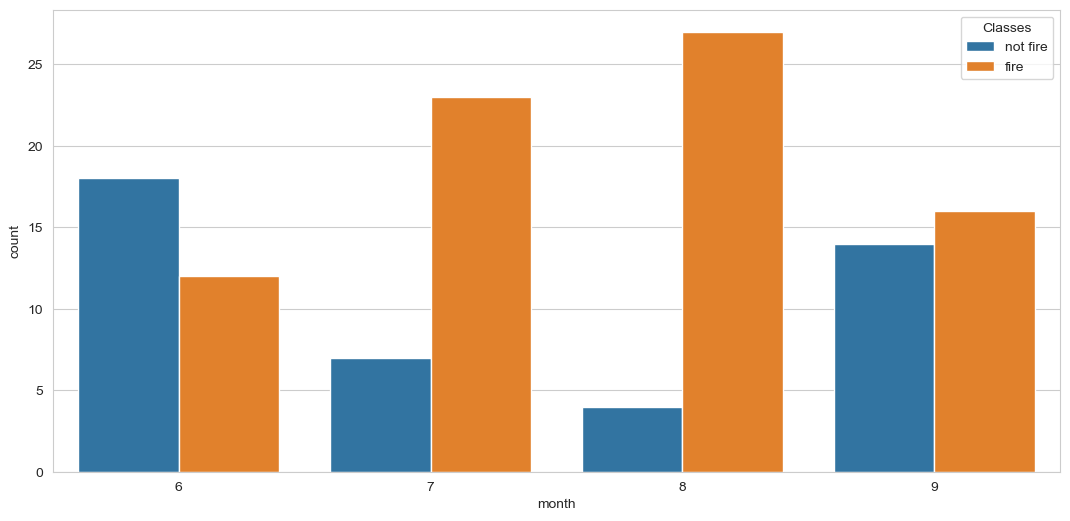

In [66]:
dftemp = df.loc[df['Region']==1] ##FOR SIDI BEL REGIONS
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)

<Axes: xlabel='month', ylabel='count'>

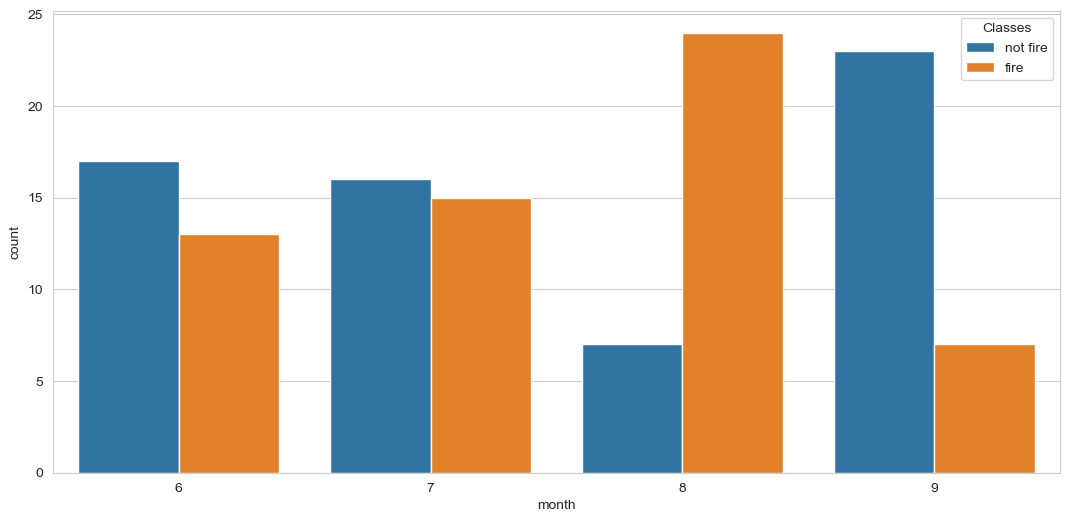

In [67]:
dftemp = df.loc[df['Region']==0] 
plt.subplots(figsize=(13,6))
sns.set_style('whitegrid')
sns.countplot(x='month',hue='Classes',data=dftemp)

In [73]:
df=df_copy

In [74]:
X = df.drop('FWI',axis = 1)
y=df['FWI']

In [75]:
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(X,y,test_size=0.25,random_state = 42)

In [81]:
corr = X_train.corr(numeric_only=True)

<Axes: >

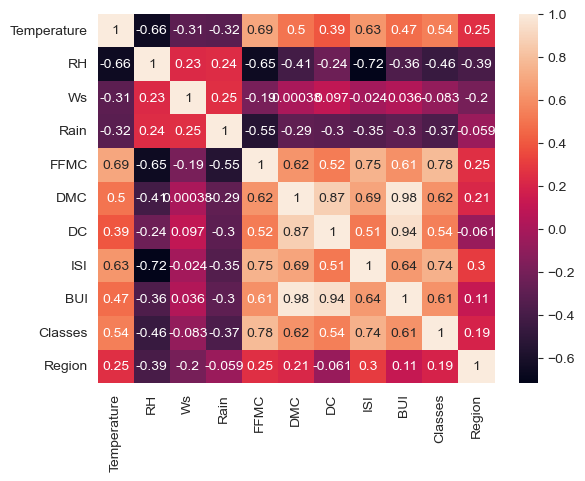

In [84]:
sns.heatmap(corr,annot=True)

In [85]:
##check for multicollinearilty

In [88]:
def multicoll(dataset, threshold):
    col_corr = set()

    corr_matrix = dataset.corr(numeric_only=True)

    for i in range(len(corr_matrix.columns)):
        for j in range(i):
            if abs(corr_matrix.iloc[i,j])>threshold:
                colname = corr_matrix.columns[i]
                col_corr.add(colname)
    return col_corr

In [97]:
x=multicoll(X_train,0.85)

In [98]:
X_train.drop(x,axis = 1, inplace=True)
X_test.drop(x,axis = 1, inplace=True)

In [99]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

* EFFECT OF SCALING

<Axes: >

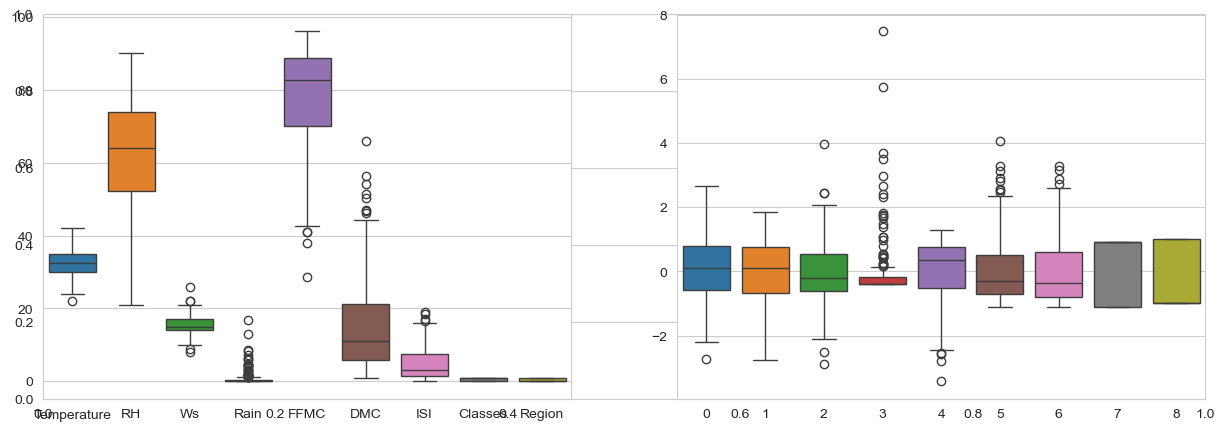

In [101]:
plt.subplots(figsize=(15,5))
plt.subplot(1,2,1)
sns.boxplot(data=X_train)

plt.subplot(1,2,2)
sns.boxplot(data=X_train_scaled)

MAE: 0.5468236465249995
R2 Score: 0.9847657384266951


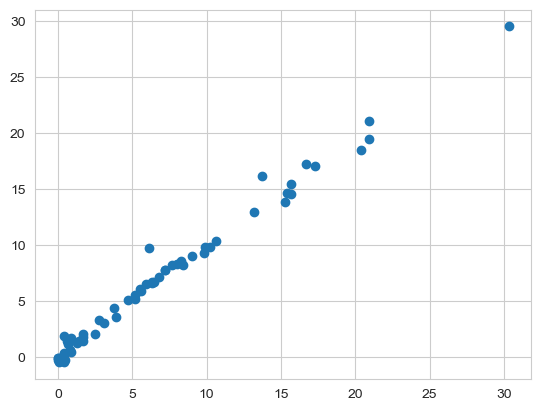

In [112]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

linreg = LinearRegression()
linreg.fit(X_train_scaled,y_train)

y_pred = linreg.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("R2 Score:",r2)

plt.scatter(y_test,y_pred)

In [113]:
#LASSO - 

MAE: 1.1331759949144087
R2 Score: 0.9492020263112388


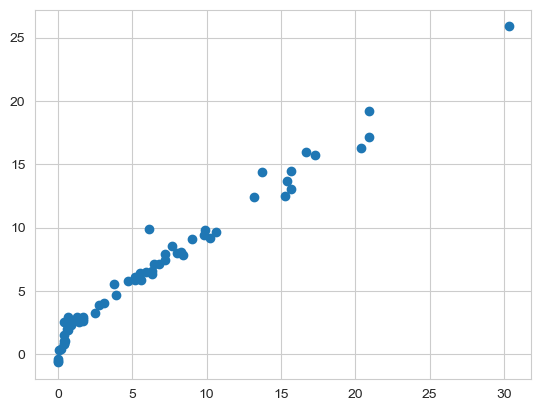

In [117]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

lasso = Lasso()
lasso.fit(X_train_scaled,y_train)

y_pred = lasso.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("R2 Score:",r2)

plt.scatter(y_test,y_pred)

In [114]:
# RIDGE 

MAE: 0.5642305340105677
R2 Score: 0.9842993364555515


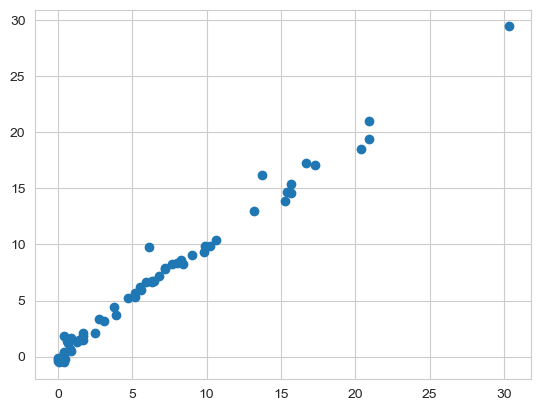

In [118]:
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

ridge = Ridge()
ridge.fit(X_train_scaled,y_train)

y_pred = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("R2 Score:",r2)

plt.scatter(y_test,y_pred)

In [116]:
#LASSO CV

MAE: 0.5468236465249995
R2 Score: 0.9847657384266951


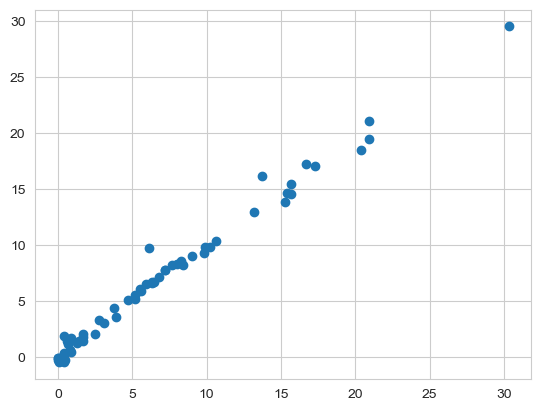

In [119]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

lassocv = LinearRegression()
lassocv.fit(X_train_scaled,y_train)

y_pred = lassocv.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("R2 Score:",r2)

plt.scatter(y_test,y_pred)

In [120]:
#RIDGE CV

MAE: 0.5642305340099703
R2 Score: 0.9842993364555502


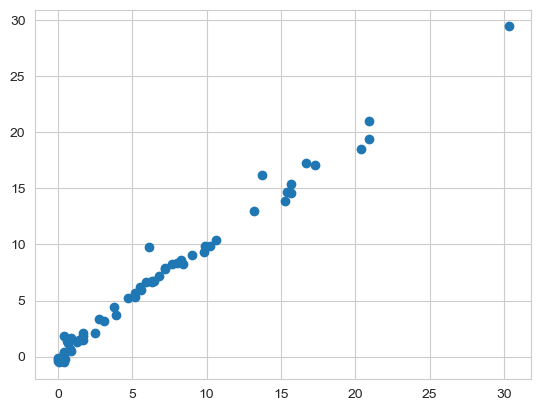

In [121]:
from sklearn.linear_model import RidgeCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

ridge = RidgeCV()
ridge.fit(X_train_scaled,y_train)

y_pred = ridge.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("R2 Score:",r2)

plt.scatter(y_test,y_pred)

MAE: 1.8822353634896005
R2 Score: 0.8753460589519703


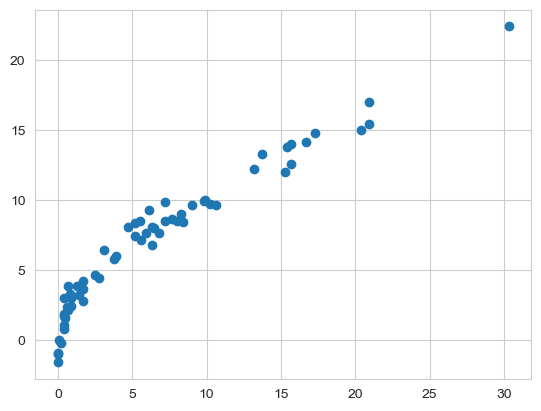

In [131]:
from sklearn.linear_model import ElasticNet
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

elastic = ElasticNet()
elastic.fit(X_train_scaled,y_train)

y_pred = elastic.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("R2 Score:",r2)

plt.scatter(y_test,y_pred)

MAE: 0.6575946731430896
R2 Score: 0.9814217587854942


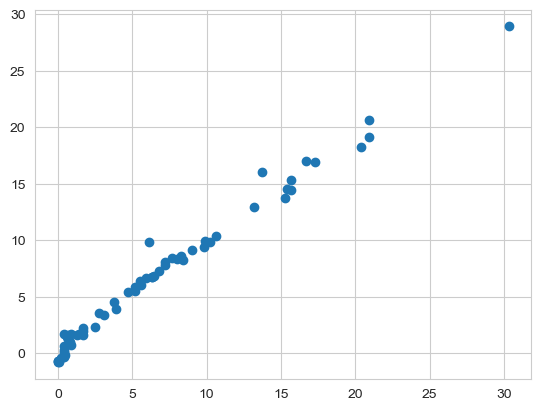

In [132]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score

elasticcv = ElasticNetCV()
elasticcv.fit(X_train_scaled,y_train)

y_pred = elasticcv.predict(X_test_scaled)

mae = mean_absolute_error(y_test,y_pred)
r2 = r2_score(y_test,y_pred)

print("MAE:",mae)
print("R2 Score:",r2)

plt.scatter(y_test,y_pred)

In [133]:
##RIDGE HAS BEST 

In [134]:
#pickle ml model and preprocessing model

In [135]:
scaler

,copy,True
,with_mean,True
,with_std,True


In [136]:
ridge

,alphas,"(0.1, ...)"
,fit_intercept,True
,scoring,None
,cv,None
,gcv_mode,None
,store_cv_results,False
,alpha_per_target,False


In [137]:
import pickle

In [138]:
pickle.dump(scaler,open('scaler.pkl','wb'))
pickle.dump(ridge,open('ridge.pkl','wb'))